In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('../dados/raw/dados_originais/t5938_pib_agropecuaria_2003_2023_ce_br.csv', sep=';', encoding='utf-8-sig')
print('shape:', df.shape)
df


shape: (15624, 10)


,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
0,N1,Brasil,1,Brasil,2003,2003,37,Produto Interno Bruto a preços correntes,Mil Reais,1717950386
1,N1,Brasil,1,Brasil,2004,2004,37,Produto Interno Bruto a preços correntes,Mil Reais,1957751224
2,N1,Brasil,1,Brasil,2005,2005,37,Produto Interno Bruto a preços correntes,Mil Reais,2170584503
3,N1,Brasil,1,Brasil,2006,2006,37,Produto Interno Bruto a preços correntes,Mil Reais,2409449916
4,N1,Brasil,1,Brasil,2007,2007,37,Produto Interno Bruto a preços correntes,Mil Reais,2720262951
...,...,...,...,...,...,...,...,...,...,...
15619,N6,Município,2314102,Viçosa do Ceará - CE,2019,2019,516,Participação do valor adicionado bruto a preço...,%,22.34
15620,N6,Município,2314102,Viçosa do Ceará - CE,2020,2020,516,Participação do valor adicionado bruto a preço...,%,23.70
15621,N6,Município,2314102,Viçosa do Ceará - CE,2021,2021,516,Participação do valor adicionado bruto a preço...,%,23.09
15622,N6,Município,2314102,Viçosa do Ceará - CE,2022,2022,516,Participação do valor adicionado bruto a preço...,%,...


In [2]:
print('DTYPES:')
print(df.dtypes)
print()
print('NULOS (NaN nativo) por coluna:')
print(df.isna().sum())
print()
print('DUPLICATAS:', df.duplicated().sum())


DTYPES:
nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
valor                       object
dtype: object

NULOS (NaN nativo) por coluna:
nivel_territorial_codigo    0
nivel_territorial_nome      0
territorio_codigo           0
territorio_nome             0
ano_codigo                  0
ano_nome                    0
variavel_codigo             0
variavel_nome               0
unidade                     0
valor                       0
dtype: int64

DUPLICATAS: 0


In [3]:
for c in df.columns:
    n = df[c].nunique()
    print(f'{c} ({n} únicos)')
    if n <= 21:
        print(df[c].value_counts().to_string())
    print()


nivel_territorial_codigo (3 únicos)
nivel_territorial_codigo
N6    15456
N1       84
N3       84

nivel_territorial_nome (3 únicos)
nivel_territorial_nome
Município               15456
Brasil                     84
Unidade da Federação       84

territorio_codigo (186 únicos)

territorio_nome (186 únicos)

ano_codigo (21 únicos)
ano_codigo
2003    744
2004    744
2005    744
2006    744
2007    744
2008    744
2009    744
2010    744
2011    744
2012    744
2013    744
2014    744
2015    744
2016    744
2017    744
2018    744
2019    744
2020    744
2021    744
2022    744
2023    744

ano_nome (21 únicos)
ano_nome
2003    744
2004    744
2005    744
2006    744
2007    744
2008    744
2009    744
2010    744
2011    744
2012    744
2013    744
2014    744
2015    744
2016    744
2017    744
2018    744
2019    744
2020    744
2021    744
2022    744
2023    744

variavel_codigo (4 únicos)
variavel_codigo
37     3906
498    3906
513    3906
516    3906

variavel_nome (4 únicos)
varia

In [4]:
# coluna 'valor' vem como object -> IBGE usa "..." como marcador de dado não disponível
mask_na = pd.to_numeric(df['valor'], errors='coerce').isna()
print('linhas com valor não numérico:', mask_na.sum())
print(df.loc[mask_na, 'valor'].value_counts())
print()

sub = df[mask_na]
print('por variavel_nome:')
print(sub['variavel_nome'].value_counts())
print()
print('por ano_nome:')
print(sub['ano_nome'].value_counts().sort_index())
print()
print('por nivel_territorial_nome:')
print(sub['nivel_territorial_nome'].value_counts())


linhas com valor não numérico: 1116
valor
...    1116
Name: count, dtype: int64

por variavel_nome:
variavel_nome
Valor adicionado bruto a preços correntes total                                                                                 372
Valor adicionado bruto a preços correntes da agropecuária                                                                       372
Participação do valor adicionado bruto a preços correntes da agropecuária no valor adicionado bruto a preços correntes total    372
Name: count, dtype: int64

por ano_nome:
ano_nome
2022    558
2023    558
Name: count, dtype: int64

por nivel_territorial_nome:
nivel_territorial_nome
Município               1104
Brasil                     6
Unidade da Federação       6
Name: count, dtype: int64


**1.116 linhas (7,1%) têm `"..."` — concentradas em VAB total/agro/participação, só nos anos 2022 e 2023 (ainda não fechados pelo IBGE). O PIB puro está 100% completo em todos os 21 anos.**


In [5]:
# N/A por coluna, individualmente (NaN nativo + marcadores IBGE tipo "...", "-", "..", "X")
markers = ['...', '-', '..', 'X', '']

for c in df.columns:
    nativo = df[c].isna().sum()
    if df[c].dtype == object:
        marcado = df[c].isin(markers).sum()
    else:
        marcado = 0
    print(f'{c}: NaN nativo={nativo}, marcador IBGE={marcado}, total N/A={nativo + marcado}')


nivel_territorial_codigo: NaN nativo=0, marcador IBGE=0, total N/A=0
nivel_territorial_nome: NaN nativo=0, marcador IBGE=0, total N/A=0
territorio_codigo: NaN nativo=0, marcador IBGE=0, total N/A=0
territorio_nome: NaN nativo=0, marcador IBGE=0, total N/A=0
ano_codigo: NaN nativo=0, marcador IBGE=0, total N/A=0
ano_nome: NaN nativo=0, marcador IBGE=0, total N/A=0
variavel_codigo: NaN nativo=0, marcador IBGE=0, total N/A=0
variavel_nome: NaN nativo=0, marcador IBGE=0, total N/A=0
unidade: NaN nativo=0, marcador IBGE=0, total N/A=0
valor: NaN nativo=0, marcador IBGE=1116, total N/A=1116


In [6]:
# tratamento: converter valor para numérico de verdade (NaN em vez de "...")
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
print(df.dtypes['valor'])
print()
print('N/A por coluna (após tratamento):')
print(df.isna().sum())
print()
df.describe(include='all')

float64

N/A por coluna (após tratamento):
nivel_territorial_codigo       0
nivel_territorial_nome         0
territorio_codigo              0
territorio_nome                0
ano_codigo                     0
ano_nome                       0
variavel_codigo                0
variavel_nome                  0
unidade                        0
valor                       1116
dtype: int64



,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,valor
count,15624,15624,1.562400e+04,15624,15624.000000,15624.000000,15624.000000,15624,15624,1.450800e+04
unique,3,3,NaN,186,NaN,NaN,NaN,4,2,NaN
top,N6,Município,NaN,Brasil,NaN,NaN,NaN,Produto Interno Bruto a preços correntes,Mil Reais,NaN
freq,15456,15456,NaN,84,NaN,NaN,NaN,3906,11718,NaN
mean,NaN,NaN,2.282232e+06,NaN,2013.000000,2013.000000,391.000000,NaN,NaN,1.403437e+07
std,NaN,NaN,2.379792e+05,NaN,6.055494,6.055494,204.502266,NaN,NaN,2.796045e+08
min,NaN,NaN,1.000000e+00,NaN,2003.000000,2003.000000,37.000000,NaN,NaN,7.000000e-02
25%,NaN,NaN,2.303808e+06,NaN,2008.000000,2008.000000,382.750000,NaN,NaN,2.944500e+03
50%,NaN,NaN,2.306652e+06,NaN,2013.000000,2013.000000,505.500000,NaN,NaN,3.818950e+04
75%,NaN,NaN,2.310605e+06,NaN,2018.000000,2018.000000,513.750000,NaN,NaN,1.306908e+05


In [7]:
# valores únicos de cada coluna (lista completa, exceto 'valor' que é numérico contínuo)
for c in df.columns:
    if c == 'valor':
        print(f'{c}: numérico contínuo, {df[c].nunique()} valores distintos (ver describe acima)')
        continue
    vals = sorted(df[c].dropna().unique().tolist())
    print(f'{c} ({len(vals)} valores):')
    print(vals)
    print()


nivel_territorial_codigo (3 valores):
['N1', 'N3', 'N6']

nivel_territorial_nome (3 valores):
['Brasil', 'Município', 'Unidade da Federação']

territorio_codigo (186 valores):
[1, 23, 2300101, 2300150, 2300200, 2300309, 2300408, 2300507, 2300606, 2300705, 2300754, 2300804, 2300903, 2301000, 2301109, 2301208, 2301257, 2301307, 2301406, 2301505, 2301604, 2301703, 2301802, 2301851, 2301901, 2301950, 2302008, 2302057, 2302107, 2302206, 2302305, 2302404, 2302503, 2302602, 2302701, 2302800, 2302909, 2303006, 2303105, 2303204, 2303303, 2303402, 2303501, 2303600, 2303659, 2303709, 2303808, 2303907, 2303931, 2303956, 2304004, 2304103, 2304202, 2304236, 2304251, 2304269, 2304277, 2304285, 2304301, 2304350, 2304400, 2304459, 2304509, 2304608, 2304657, 2304707, 2304806, 2304905, 2304954, 2305001, 2305100, 2305209, 2305233, 2305266, 2305308, 2305332, 2305357, 2305407, 2305506, 2305605, 2305654, 2305704, 2305803, 2305902, 2306009, 2306108, 2306207, 2306256, 2306306, 2306405, 2306504, 2306553, 230660

In [8]:
print(df['unidade'].value_counts())
print()
print(df.groupby('unidade')['variavel_nome'].unique())


unidade
Mil Reais    11718
%             3906
Name: count, dtype: int64

unidade
%            [Participação do valor adicionado bruto a preç...
Mil Reais    [Produto Interno Bruto a preços correntes, Val...
Name: variavel_nome, dtype: object


In [9]:
print('ano min:', df['ano_nome'].min())
print('ano max:', df['ano_nome'].max())


ano min: 2003
ano max: 2023


In [10]:
# colunas que funcionam como código (chave de junção / identificador)
colunas_codigo = [c for c in df.columns if c.endswith('_codigo')]
print(colunas_codigo)


['nivel_territorial_codigo', 'territorio_codigo', 'ano_codigo', 'variavel_codigo']


**Evolução do PIB: Ceará x top 10 municípios (2003-2023)**

Plota o PIB total do Ceará (linha preta) contra o PIB dos 10 municípios de maior PIB em 2023 (`nlargest`), cada um filtrado por `variavel_nome == "Produto Interno Bruto a preços correntes"` e ordenado por ano. Eixo Y em log porque o PIB estadual é ordens de grandeza maior que o dos municípios individuais — sem log, as linhas dos municípios ficariam achatadas perto de zero.

Interpretação: o PIB do Ceará cresce de R$ 32,7 bi (2003) para R$ 232,2 bi (2023), 7,1x — valores a preços correntes, sem deflacionar. Fortaleza segue líder folgada, mas cresce mais devagar que a maioria do top 10 (5,7x): sua fatia do PIB estadual cai de 46,6% pra 37,4%, indício de desconcentração relativa. Destaque isolado é São Gonçalo do Amarante, que salta 70x (R$ 98,7 mi -> R$ 6,9 bi) — coerente com a instalação do Complexo Industrial e Portuário do Pecém no período; Caucaia, Aquiraz e Eusébio (região metropolitana) também crescem acima de 10x. Sobral e Juazeiro do Norte, polos fora da metropolitana, crescem perto do ritmo de Fortaleza (6,0x e 9,0x), mantendo posição estável.


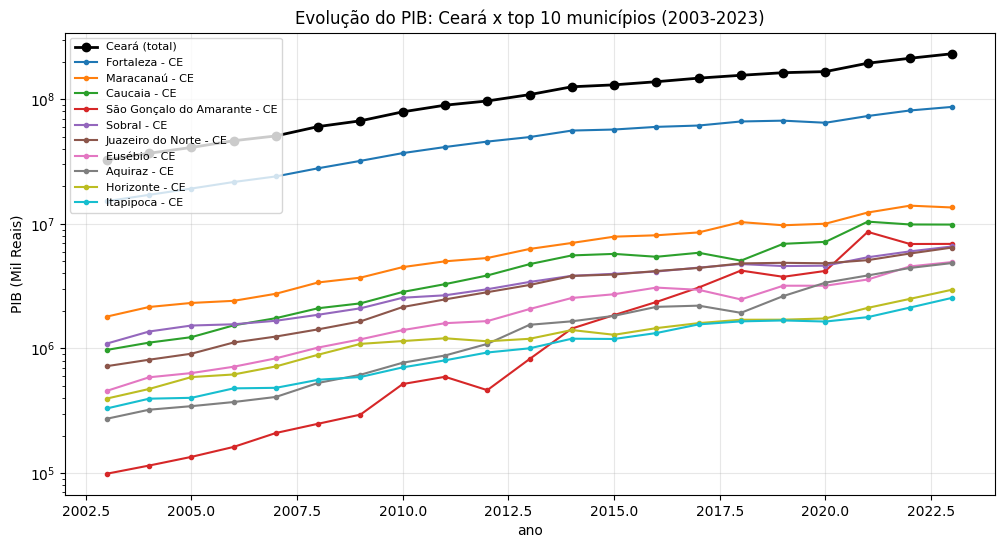

In [11]:
import matplotlib.pyplot as plt

# evolução do PIB do Ceará x top 10 municípios ao longo dos anos
pib_ce = df[
    (df['territorio_nome'] == 'Ceará') &
    (df['variavel_nome'] == 'Produto Interno Bruto a preços correntes')
].sort_values('ano_nome')

top10 = df[
    (df['nivel_territorial_nome'] == 'Município') &
    (df['variavel_nome'] == 'Produto Interno Bruto a preços correntes') &
    (df['ano_nome'] == 2023)
].nlargest(10, 'valor')['territorio_nome']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_ce['ano_nome'], pib_ce['valor'], marker='o', color='black', linewidth=2, label='Ceará (total)')

for municipio in top10:
    pib_mun = df[
        (df['territorio_nome'] == municipio) &
        (df['variavel_nome'] == 'Produto Interno Bruto a preços correntes')
    ].sort_values('ano_nome')
    ax.plot(pib_mun['ano_nome'], pib_mun['valor'], marker='.', label=municipio)

ax.set_xlabel('ano')
ax.set_ylabel('PIB (Mil Reais)')
ax.set_title('Evolução do PIB: Ceará x top 10 municípios (2003-2023)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
plt.show()


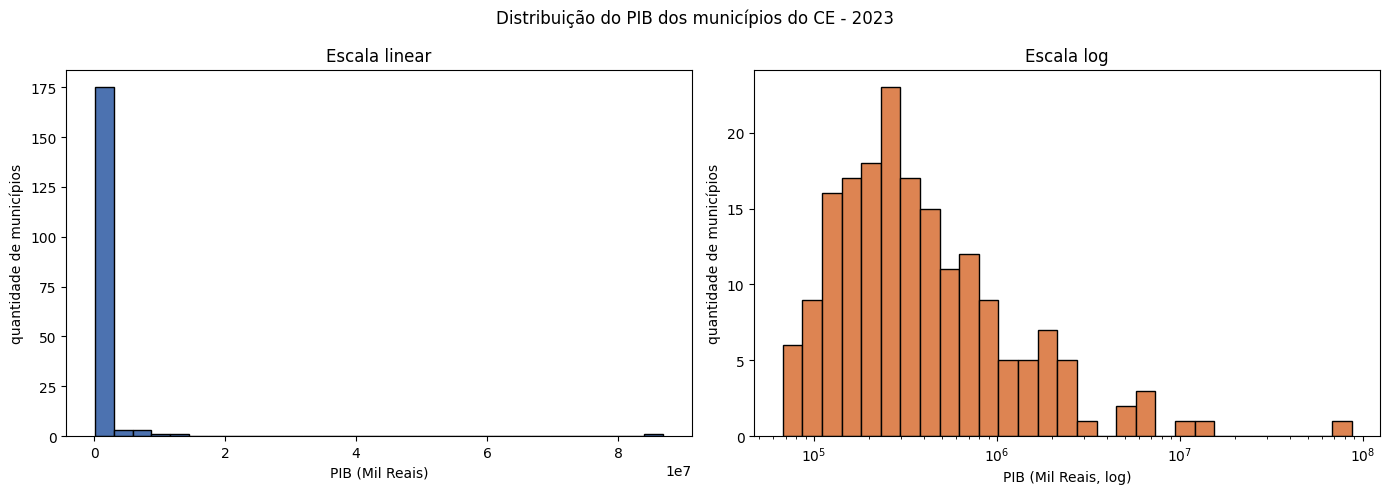

In [12]:
import numpy as np

pib_municipio = df[
    (df['nivel_territorial_nome'] == 'Município') &
    (df['variavel_nome'] == 'Produto Interno Bruto a preços correntes') &
    (df['ano_nome'] == 2023)
]['valor']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pib_municipio, bins=30, color='#4c72b0', edgecolor='black')
axes[0].set_xlabel('PIB (Mil Reais)')
axes[0].set_ylabel('quantidade de municípios')
axes[0].set_title('Escala linear')

axes[1].hist(pib_municipio, bins=np.logspace(np.log10(pib_municipio.min()), np.log10(pib_municipio.max()), 30),
             color='#dd8452', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('PIB (Mil Reais, log)')
axes[1].set_ylabel('quantidade de municípios')
axes[1].set_title('Escala log')

fig.suptitle('Distribuição do PIB dos municípios do CE - 2023')
plt.tight_layout()
plt.show()


In [13]:
# schema check: ano_codigo == ano_nome sempre? cobertura completa de município x ano x variável?
print('ano_codigo == ano_nome em todas as linhas:', (df['ano_codigo'] == df['ano_nome']).all())
print()

esperado = 186 * 21 * 4
print('linhas esperadas (território x ano x variável):', esperado)
print('linhas reais:', len(df))
print()

combinacoes = df.groupby(['territorio_codigo', 'ano_nome'])['variavel_nome'].count()
faltando = combinacoes[combinacoes != 4]
print('combinações território-ano sem as 4 variáveis:', len(faltando))
if len(faltando) > 0:
    print(faltando)


ano_codigo == ano_nome em todas as linhas: True

linhas esperadas (território x ano x variável): 15624
linhas reais: 15624

combinações território-ano sem as 4 variáveis: 0


**Schema 100% consistente: `ano_codigo == ano_nome` sempre, 15.624 linhas batem exato com o esperado (186 territórios × 21 anos × 4 variáveis), nenhuma combinação território-ano incompleta.**


In [14]:
# outlier check: valor negativo/zero, e outliers via IQR por variável x nível territorial
# (separar nível territorial é essencial: Brasil/Ceará/município têm escalas muito diferentes)
print('valores <= 0:', (df['valor'] <= 0).sum())
print()

for nivel in df['nivel_territorial_nome'].unique():
    print(f'=== {nivel} ===')
    for var in df['variavel_nome'].unique():
        sub = df[(df['variavel_nome'] == var) & (df['nivel_territorial_nome'] == nivel)]['valor'].dropna()
        if len(sub) == 0:
            continue
        q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
        iqr = q3 - q1
        limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = sub[(sub < limite_inf) | (sub > limite_sup)]
        print(f'  {var[:50]}: {len(outliers)} outliers de {len(sub)}')
    print()

# exemplo: outliers de PIB só entre municípios
sub = df[(df['variavel_nome'] == 'Produto Interno Bruto a preços correntes') & (df['nivel_territorial_nome'] == 'Município')].dropna(subset=['valor'])
q1, q3 = sub['valor'].quantile(0.25), sub['valor'].quantile(0.75)
iqr = q3 - q1
limite_sup = q3 + 1.5 * iqr
print('--- outliers PIB município (5 maiores) ---')
print(sub[sub['valor'] > limite_sup].nlargest(5, 'valor')[['territorio_nome', 'ano_nome', 'valor']].to_string(index=False))
print()
print('--- normais PIB município (5 aleatórios) ---')
normais = sub[sub['valor'] <= limite_sup]
print(normais.sample(5, random_state=1)[['territorio_nome', 'ano_nome', 'valor']].to_string(index=False))


valores <= 0: 0

=== Brasil ===
  Produto Interno Bruto a preços correntes: 0 outliers de 21
  Valor adicionado bruto a preços correntes total: 0 outliers de 19
  Valor adicionado bruto a preços correntes da agrop: 1 outliers de 19
  Participação do valor adicionado bruto a preços co: 4 outliers de 19

=== Unidade da Federação ===
  Produto Interno Bruto a preços correntes: 0 outliers de 21
  Valor adicionado bruto a preços correntes total: 0 outliers de 19
  Valor adicionado bruto a preços correntes da agrop: 0 outliers de 19
  Participação do valor adicionado bruto a preços co: 0 outliers de 19

=== Município ===
  Produto Interno Bruto a preços correntes: 442 outliers de 3864
  Valor adicionado bruto a preços correntes total: 397 outliers de 3496
  Valor adicionado bruto a preços correntes da agrop: 254 outliers de 3496
  Participação do valor adicionado bruto a preços co: 79 outliers de 3496

--- outliers PIB município (5 maiores) ---
territorio_nome  ano_nome      valor
 Fortaleza

In [15]:
# comparação antes x depois de remover outliers (IQR), só município, por variável
df_municipio = df[df['nivel_territorial_nome'] == 'Município'].copy()

partes_sem_outlier = []
for var in df_municipio['variavel_nome'].unique():
    sub = df_municipio[df_municipio['variavel_nome'] == var].dropna(subset=['valor'])
    q1, q3 = sub['valor'].quantile(0.25), sub['valor'].quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    partes_sem_outlier.append(sub[(sub['valor'] >= limite_inf) & (sub['valor'] <= limite_sup)])

df_municipio_sem_outlier = pd.concat(partes_sem_outlier)

print('linhas antes:', len(df_municipio))
print('linhas depois:', len(df_municipio_sem_outlier))
print('removidas:', len(df_municipio) - len(df_municipio_sem_outlier))
print()

print('--- describe antes (por variável) ---')
print(df_municipio.groupby('variavel_nome')['valor'].describe())
print()
print('--- describe depois (por variável, sem outlier) ---')
print(df_municipio_sem_outlier.groupby('variavel_nome')['valor'].describe())


linhas antes: 15456
linhas depois: 13180
removidas: 2276

--- describe antes (por variável) ---
                                                     count           mean           std      min       25%        50%        75%          max
variavel_nome                                                                                                                                
Participação do valor adicionado bruto a preços...  3496.0      16.875569  9.747850e+00     0.07     10.02      15.15      22.38        67.29
Produto Interno Bruto a preços correntes            3864.0  616139.116977  3.940754e+06  9609.00  62633.25  128264.50  302124.50  86939832.00
Valor adicionado bruto a preços correntes da ag...  3496.0   27779.116705  3.473303e+04  1313.00   8352.50   16989.00   33878.50    370244.00
Valor adicionado bruto a preços correntes total     3496.0  483549.260011  3.059432e+06  9390.00  56083.00  110537.00  246037.25  60626428.00

--- describe depois (por variável, sem outlier) ---

In [16]:
# mostra as linhas de PIB removidas (outliers) x as que ficaram (amostra), lado a lado
var_ref = 'Produto Interno Bruto a preços correntes'
sub = df_municipio[df_municipio['variavel_nome'] == var_ref].dropna(subset=['valor'])
q1, q3 = sub['valor'].quantile(0.25), sub['valor'].quantile(0.75)
iqr = q3 - q1
limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

removidos = sub[(sub['valor'] < limite_inf) | (sub['valor'] > limite_sup)]
mantidos = sub[(sub['valor'] >= limite_inf) & (sub['valor'] <= limite_sup)]

print(f'limite IQR: [{limite_inf:.0f}, {limite_sup:.0f}]')
print(f'removidos: {len(removidos)} | mantidos: {len(mantidos)}')
print()
print('--- REMOVIDOS (outliers, 10 maiores) ---')
print(removidos.nlargest(10, 'valor')[['territorio_nome', 'ano_nome', 'valor']].to_string(index=False))
print()
print('--- MANTIDOS (amostra de 10) ---')
print(mantidos.sample(10, random_state=1)[['territorio_nome', 'ano_nome', 'valor']].to_string(index=False))


limite IQR: [-296604, 661361]
removidos: 442 | mantidos: 3422

--- REMOVIDOS (outliers, 10 maiores) ---
territorio_nome  ano_nome      valor
 Fortaleza - CE      2023 86939832.0
 Fortaleza - CE      2022 81362333.0
 Fortaleza - CE      2021 73437739.0
 Fortaleza - CE      2019 67401430.0
 Fortaleza - CE      2018 66381302.0
 Fortaleza - CE      2020 64821582.0
 Fortaleza - CE      2017 61592347.0
 Fortaleza - CE      2016 60088001.0
 Fortaleza - CE      2015 57211200.0
 Fortaleza - CE      2014 56116644.0

--- MANTIDOS (amostra de 10) ---
 territorio_nome  ano_nome    valor
   Madalena - CE      2014 113448.0
  Granjeiro - CE      2020  47139.0
Martinópole - CE      2009  28292.0
     Umirim - CE      2008  51982.0
  Porteiras - CE      2003  33173.0
      Graça - CE      2008  43196.0
 Potiretama - CE      2007  16781.0
   Barreira - CE      2019 183368.0
     Icapuí - CE      2016 245693.0
Ibicuitinga - CE      2013  60583.0


**Outlier ≠ erro: os 442 "outliers" de PIB municipal (11,4%) são quase todos Fortaleza em anos diferentes — concentração econômica real, não dado ruim. IQR não é o método certo pra "limpar" essa variável.**


In [17]:
# mapeamento código <-> nome: cada código sempre aponta pro mesmo nome (1:1)?
mapa_nivel = df.groupby('nivel_territorial_codigo')['nivel_territorial_nome'].nunique()
mapa_variavel = df.groupby('variavel_codigo')['variavel_nome'].nunique()

print('nivel_territorial_codigo -> nivel_territorial_nome (deve ser sempre 1):')
print(mapa_nivel)
print('OK' if (mapa_nivel == 1).all() else 'INCONSISTENTE')
print()

print('variavel_codigo -> variavel_nome (deve ser sempre 1):')
print(mapa_variavel)
print('OK' if (mapa_variavel == 1).all() else 'INCONSISTENTE')


nivel_territorial_codigo -> nivel_territorial_nome (deve ser sempre 1):
nivel_territorial_codigo
N1    1
N3    1
N6    1
Name: nivel_territorial_nome, dtype: int64
OK

variavel_codigo -> variavel_nome (deve ser sempre 1):
variavel_codigo
37     1
498    1
513    1
516    1
Name: variavel_nome, dtype: int64
OK


In [18]:
# completude por município individual: cada um dos 184 tem exatamente 84 linhas (21 anos x 4 variáveis)?
linhas_por_municipio = df[df['nivel_territorial_nome'] == 'Município'].groupby('territorio_nome').size()
print('municípios distintos:', linhas_por_municipio.shape[0])
print('todos com 84 linhas:', (linhas_por_municipio == 84).all())
if not (linhas_por_municipio == 84).all():
    print(linhas_por_municipio[linhas_por_municipio != 84])
print()

# padrão do nome: todo município termina em " - CE"?
mun = df[df['nivel_territorial_nome'] == 'Município']
sem_sufixo = mun[~mun['territorio_nome'].str.endswith(' - CE')]['territorio_nome'].unique()
print('municípios sem sufixo " - CE":', sem_sufixo)

nao_mun = df[df['nivel_territorial_nome'] != 'Município']
com_sufixo = nao_mun[nao_mun['territorio_nome'].str.endswith(' - CE')]['territorio_nome'].unique()
print('não-município com sufixo " - CE" (não deveria ter):', com_sufixo)


municípios distintos: 184
todos com 84 linhas: True

municípios sem sufixo " - CE": []
não-município com sufixo " - CE" (não deveria ter): []


**Completude 100%: os 184 municípios têm exatamente 84 linhas cada (21 anos × 4 variáveis), sem buraco estrutural. Todo nome de município termina em `" - CE"`, Brasil/Ceará nunca — zero confusão entre níveis.**


## Resumo do inventário — PIB Agropecuária (t5938)

**Estrutura**
- 15.624 linhas x 10 colunas, sem duplicatas
- Granularidade: território (Brasil/UF/Município) x ano x variável
- 186 territórios (Brasil, Ceará, 184 municípios), 21 anos (2003-2023), 4 variáveis

**Colunas código** (chave/identificador): `nivel_territorial_codigo`, `territorio_codigo`, `ano_codigo`, `variavel_codigo` — todos com mapeamento 1:1 confirmado pro respectivo nome.

**Variáveis** (4): PIB, VAB total, VAB agropecuária (todas em Mil Reais) e Participação da agropecuária no VAB total (%).

**N/A**: nenhum NaN nativo. IBGE usa marcador de texto `"..."` — 1.116 linhas afetadas (~7%), concentradas nas 3 variáveis derivadas (VAB total/agro/participação) nos anos 2022-2023, ainda não fechados pelo IBGE. PIB (variável principal) 100% completo em todos os anos.

**Completude**: todo município tem exatamente 84 linhas (21 anos x 4 variáveis) — sem buracos estruturais. Todo `territorio_nome` de município termina em " - CE"; Brasil/Ceará não têm o sufixo, sem confusão entre níveis.

**Outliers**: distribuição de PIB entre municípios é fortemente assimétrica (poucos grandes, muitos pequenos) — concentração econômica real, não erro de dado. Fortaleza sozinha domina a maior parte dos outliers em quase todos os anos. IQR não é o método certo pra "limpar" esse tipo de variável.

**Chave de junção com PAM/PPM/geojson**: `territorio_codigo` + `ano_nome` (ou `ano_codigo`, idêntico). Confirmado que `territorio_codigo` bate com `codarea` do geojson municipal.
